<a href="https://colab.research.google.com/github/skpaul59/Codtyper/blob/main/Toughness_Adabosst_20%25_Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/property_Toughness.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,Sample_ID,Al2O3_wt_pct,Overlap_length_mm,Toughness
0,Base_1,0,15,0.392571
1,Base_2,0,15,0.399483
2,Base_3,0,15,0.402901
3,Base_4,0,15,0.406297
4,Base_5,0,15,0.408852


Next, I'll check the information about the DataFrame, including data types and non-null values, and display descriptive statistics.

In [11]:
# Display information about the DataFrame (data types, non-null counts)
df.info()

# Display descriptive statistics of the DataFrame
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Sample_ID          150 non-null    object 
 1   Al2O3_wt_pct       150 non-null    int64  
 2   Overlap_length_mm  150 non-null    int64  
 3   Toughness          150 non-null    float64
dtypes: float64(1), int64(2), object(1)
memory usage: 4.8+ KB


,Al2O3_wt_pct,Overlap_length_mm,Toughness
count,150.000000,150.000000,150.000000
mean,2.000000,25.000000,1.784556
std,1.418951,7.094757,1.121364
min,0.000000,15.000000,0.392571
25%,1.000000,20.000000,0.955766
50%,2.000000,25.000000,1.591360
75%,3.000000,30.000000,2.417225
max,4.000000,35.000000,5.023847


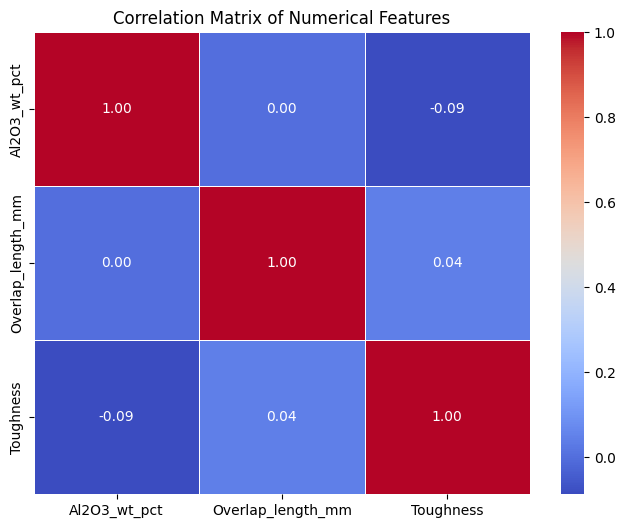

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix for numerical columns
correlation_matrix = df.select_dtypes(include=['number']).corr()

# Create a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

Now, I'll implement a Random Forest Regressor model, perform hyperparameter tuning using GridSearchCV, and then evaluate the model's performance using MAE, MSE, and R2 score.

In [20]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize the base estimator for AdaBoost
# A shallow Decision Tree is often a good base estimator for AdaBoost
dt = DecisionTreeRegressor(random_state=42)

# Initialize the AdaBoost Regressor
# Note: AdaBoost typically works with simpler base estimators
ada = AdaBoostRegressor(estimator=dt, random_state=42)

# Define the parameter grid for hyperparameter tuning for AdaBoost
param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 0.5, 1.0],
    'estimator__max_depth': [1, 2, 3, 4] # Tuning max_depth of the base DecisionTreeRegressor
}

# Perform GridSearchCV for hyperparameter tuning
grid_search_ada = GridSearchCV(estimator=ada, param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=2, scoring='neg_mean_squared_error')
grid_search_ada.fit(X_train, y_train)

# Get the best estimator
best_ada = grid_search_ada.best_estimator_

print(f"Best Hyperparameters for AdaBoost: {grid_search_ada.best_params_}")

# Make predictions on the test set
y_pred_ada = best_ada.predict(X_test)

# Evaluate the model
mae_ada = mean_absolute_error(y_test, y_pred_ada)
mse_ada = mean_squared_error(y_test, y_pred_ada)
r2_ada = r2_score(y_test, y_pred_ada)

print(f"\nAdaBoost Mean Absolute Error (MAE): {mae_ada:.4f}")
print(f"AdaBoost Mean Squared Error (MSE): {mse_ada:.4f}")
print(f"AdaBoost R-squared (R2) Score: {r2_ada:.4f}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Hyperparameters for AdaBoost: {'estimator__max_depth': 4, 'learning_rate': 0.5, 'n_estimators': 50}

AdaBoost Mean Absolute Error (MAE): 0.2354
AdaBoost Mean Squared Error (MSE): 0.1105
AdaBoost R-squared (R2) Score: 0.9281


Now, let's visualize the feature importances to understand which features contribute most to the model's predictions.

/tmp/ipykernel_940/4089536896.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df_ada, palette='viridis')


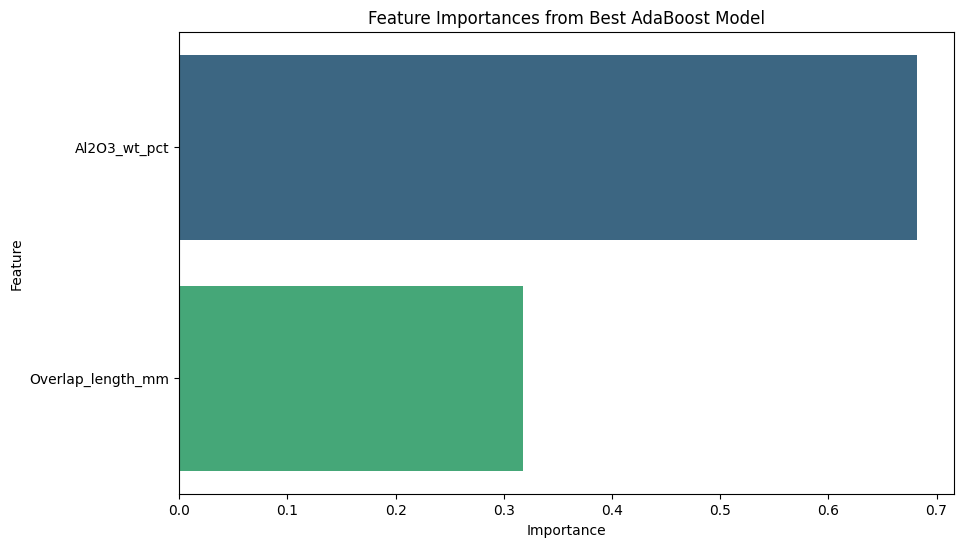

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the best AdaBoost model
feature_importances_ada = best_ada.feature_importances_

# Get feature names from the training data
feature_names = X_train.columns

# Create a DataFrame for better visualization
importance_df_ada = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances_ada})
importance_df_ada = importance_df_ada.sort_values(by='Importance', ascending=False)

# Plot feature importances
fig = plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df_ada, palette='viridis')
plt.title('Feature Importances from Best AdaBoost Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

Here is the horizontal bar chart displaying the feature importances:

/tmp/ipykernel_940/4089536896.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df_ada, palette='viridis')


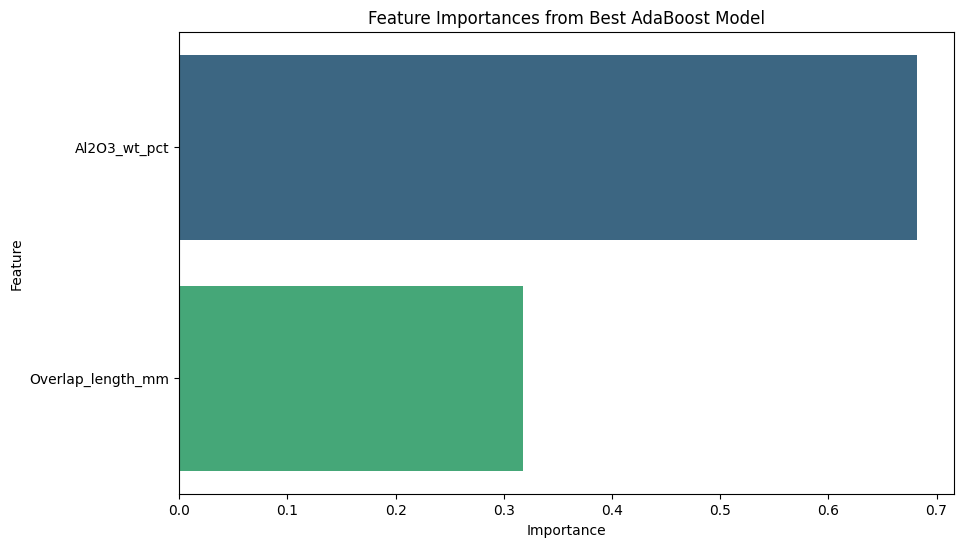

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the best AdaBoost model
feature_importances_ada = best_ada.feature_importances_

# Get feature names from the training data
feature_names = X_train.columns

# Create a DataFrame for better visualization
importance_df_ada = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances_ada})
importance_df_ada = importance_df_ada.sort_values(by='Importance', ascending=False)

# Plot feature importances
fig = plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df_ada, palette='viridis')
plt.title('Feature Importances from Best AdaBoost Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

Let's visualize the model's performance by comparing the actual toughness values with the predicted toughness values using a scatter plot.

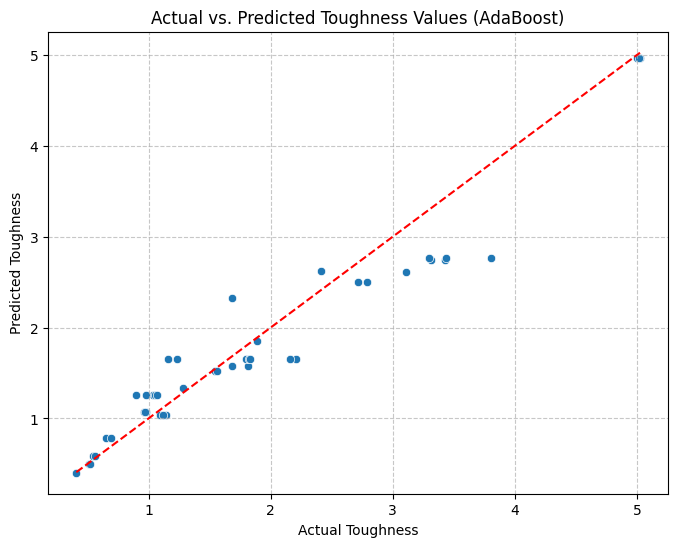

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot of actual vs. predicted values for AdaBoost
fig = plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_ada) # Using y_pred_ada for AdaBoost predictions

# Add a diagonal line for perfect prediction
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')

plt.title('Actual vs. Predicted Toughness Values (AdaBoost)')
plt.xlabel('Actual Toughness')
plt.ylabel('Predicted Toughness')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

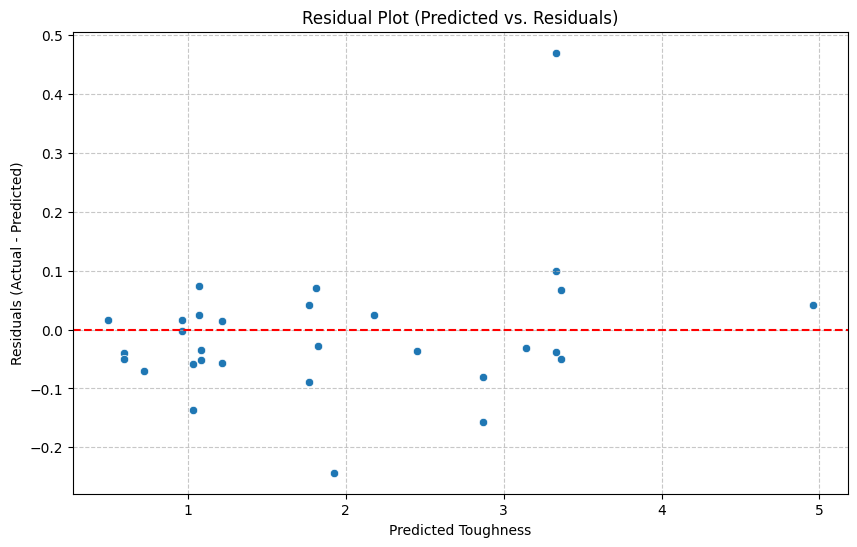

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate residuals
residuals = y_test - y_pred

# Create a residual plot
fig = plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color='r', linestyle='--') # Add a horizontal line at y=0

plt.title('Residual Plot (Predicted vs. Residuals)')
plt.xlabel('Predicted Toughness')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Now that the model is trained and evaluated, let's save it to a file so it can be reloaded and used later without needing to retrain.

In [18]:
import joblib

# Define the filename for the saved model
model_filename = 'random_forest_toughness_model.joblib'

# Save the best Random Forest model to the file
joblib.dump(best_rf, model_filename)

print(f"Model saved successfully to {model_filename}")

Model saved successfully to random_forest_toughness_model.joblib


Now, I'll prepare the data for modeling by separating features (X) and target (y), handling the `Sample_ID` column, checking for missing values, and splitting the data into training and testing sets.

In [19]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df.drop(['Toughness', 'Sample_ID'], axis=1)
y = df['Toughness']

# Check for missing values
print('Missing values in features:\n', X.isnull().sum())
print('\nMissing values in target:\n', y.isnull().sum())

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('\nX_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)

Missing values in features:
 Al2O3_wt_pct         0
Overlap_length_mm    0
dtype: int64

Missing values in target:
 0

X_train shape: (105, 2)
X_test shape: (45, 2)
y_train shape: (105,)
y_test shape: (45,)
